In [1]:
import pandas as pd
import calliope as cp
import matplotlib.pyplot as plt
import geopandas as gpd

In [10]:
output_file = "model_results_pypsa_nuclear_must_run.nc" #use your model results

model = cp.read_netcdf(output_file)

print("Model results reloaded from file")

Model results reloaded from file


In [22]:
transmission_carrier_prod = model.results.carrier_prod.sel(
    loc_tech_carriers_prod= model.results.carrier_prod.loc_tech_carriers_prod.str.contains("transmission_hvac|transmission_hvdc")
)
transmission_carrier_prod

<xarray.DataArray 'carrier_prod' (loc_tech_carriers_prod: 46, timesteps: 8760)>
array([[0.00000000e+00, 0.00000000e+00, 1.87222183e+00, ...,
        1.97943009e+00, 0.00000000e+00, 1.85378923e+00],
       [0.00000000e+00, 2.20259133e+00, 2.19445840e+00, ...,
        2.35980000e+00, 2.35980000e+00, 2.35980000e+00],
       [9.99996943e-01, 0.00000000e+00, 9.99996416e-01, ...,
        9.99995697e-01, 9.99995425e-01, 0.00000000e+00],
       ...,
       [1.00000000e+00, 3.21080801e-06, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 4.55199009e-06],
       [2.02145397e+00, 2.06194907e+00, 2.08062128e+00, ...,
        1.64105445e+00, 0.00000000e+00, 1.68785818e+00],
       [6.99997644e-01, 0.00000000e+00, 6.99997383e-01, ...,
        6.99997116e-01, 6.99996925e-01, 6.99996935e-01]])
Coordinates:
  * loc_tech_carriers_prod  (loc_tech_carriers_prod) object 'NL41::transmissi...
  * timesteps               (timesteps) datetime64[ns] 2050-01-01 ... 2050-12...
Attributes:
    is_result:  1

In [23]:
transmission_carrier_prod = model.results.carrier_prod.sel(
    loc_tech_carriers_prod= model.results.carrier_prod.loc_tech_carriers_prod.str.contains("transmission_hvac|transmission_hvdc")
)
transmission_carrier_prod

<xarray.DataArray 'carrier_prod' (loc_tech_carriers_prod: 46, timesteps: 8760)>
array([[0.00000000e+00, 0.00000000e+00, 1.87222183e+00, ...,
        1.97943009e+00, 0.00000000e+00, 1.85378923e+00],
       [0.00000000e+00, 2.20259133e+00, 2.19445840e+00, ...,
        2.35980000e+00, 2.35980000e+00, 2.35980000e+00],
       [9.99996943e-01, 0.00000000e+00, 9.99996416e-01, ...,
        9.99995697e-01, 9.99995425e-01, 0.00000000e+00],
       ...,
       [1.00000000e+00, 3.21080801e-06, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 4.55199009e-06],
       [2.02145397e+00, 2.06194907e+00, 2.08062128e+00, ...,
        1.64105445e+00, 0.00000000e+00, 1.68785818e+00],
       [6.99997644e-01, 0.00000000e+00, 6.99997383e-01, ...,
        6.99997116e-01, 6.99996925e-01, 6.99996935e-01]])
Coordinates:
  * loc_tech_carriers_prod  (loc_tech_carriers_prod) object 'NL41::transmissi...
  * timesteps               (timesteps) datetime64[ns] 2050-01-01 ... 2050-12...
Attributes:
    is_result:  1

In [24]:
#read the csv from your output
df1=df = pd.read_csv("net_carrier_flow_pypsa.csv")
df2=df = pd.read_csv("net_carrier_flow_tennet.csv")

In [25]:
df1 = df1.copy()

# Define a function to extract pairs
def extract_pair(loc_tech):
    parts = loc_tech.split("::")
    location1 = parts[0]
    location2 = parts[1].split(":")[1]  
    return tuple(sorted([location1, location2]))  # Sort to ensure consistent pair representation

# Add the "pairs" column to the DataFrame
df1["pairs"] = df1["loc_tech_carriers_prod"].apply(extract_pair)

# Group by "pairs" and "timesteps" and take the row with the maximum net_carrier_flow
result = (
    df1.loc[df1.groupby(["pairs", "timesteps"])["net_carrier_flow"].idxmax()]
    .reset_index(drop=True)  # Reset index for clarity
)

print(result)


                           loc_tech_carriers_prod            timesteps  \
0         BE::transmission_hvac:NL34::electricity  2050-01-01 00:00:00   
1         BE::transmission_hvac:NL34::electricity  2050-01-01 01:00:00   
2         BE::transmission_hvac:NL34::electricity  2050-01-01 02:00:00   
3         BE::transmission_hvac:NL34::electricity  2050-01-01 03:00:00   
4         BE::transmission_hvac:NL34::electricity  2050-01-01 04:00:00   
...                                           ...                  ...   
201475  NL41::transmission_hvac:NL42::electricity  2050-12-31 19:00:00   
201476  NL41::transmission_hvac:NL42::electricity  2050-12-31 20:00:00   
201477  NL41::transmission_hvac:NL42::electricity  2050-12-31 21:00:00   
201478  NL41::transmission_hvac:NL42::electricity  2050-12-31 22:00:00   
201479  NL41::transmission_hvac:NL42::electricity  2050-12-31 23:00:00   

        net_carrier_flow         pairs  
0               0.630608    (BE, NL34)  
1               0.612475    (

In [26]:
transmission_energy_cap = model.inputs.energy_cap_equals.sel(
    loc_techs=model.inputs.energy_cap_equals.loc_techs.str.contains("transmission_hvac|transmission_hvdc"))
transmission_energy_cap

<xarray.DataArray 'energy_cap_equals' (loc_techs: 46)>
array([2.3198, 2.2568, 2.2403, 2.9266, 0.6776, 2.3598, 2.3203, 0.7   ,
       2.3684, 0.6774, 2.2296, 2.91  , 2.3662, 4.1989, 2.2448, 2.2568,
       4.1989, 2.3493, 2.3633, 0.7   , 1.    , 2.2755, 2.3633, 2.2493,
       2.8774, 0.7   , 2.91  , 2.2755, 2.3203, 2.3684, 2.2493, 1.    ,
       2.2296, 0.7   , 2.8774, 2.2891, 2.2403, 0.6774, 2.3598, 2.9266,
       2.3493, 0.6776, 2.2448, 2.2891, 2.3662, 2.3198])
Coordinates:
  * loc_techs  (loc_techs) object 'NL32::transmission_hvac:NL31' ... 'NL31::t...
Attributes:
    is_result:  0

In [27]:
# Ensure loc_techs is treated as Python objects for flexible string handling
transmission_energy_cap_with_carrier = transmission_energy_cap.copy()

# Convert loc_techs to an object dtype for proper string concatenation
transmission_energy_cap_with_carrier = transmission_energy_cap_with_carrier.assign_coords(
    loc_techs=transmission_energy_cap_with_carrier.loc_techs.astype(object) + "::electricity"
)

# Display the updated DataArray
transmission_energy_cap_with_carrier

<xarray.DataArray 'energy_cap_equals' (loc_techs: 46)>
array([2.3198, 2.2568, 2.2403, 2.9266, 0.6776, 2.3598, 2.3203, 0.7   ,
       2.3684, 0.6774, 2.2296, 2.91  , 2.3662, 4.1989, 2.2448, 2.2568,
       4.1989, 2.3493, 2.3633, 0.7   , 1.    , 2.2755, 2.3633, 2.2493,
       2.8774, 0.7   , 2.91  , 2.2755, 2.3203, 2.3684, 2.2493, 1.    ,
       2.2296, 0.7   , 2.8774, 2.2891, 2.2403, 0.6774, 2.3598, 2.9266,
       2.3493, 0.6776, 2.2448, 2.2891, 2.3662, 2.3198])
Coordinates:
  * loc_techs  (loc_techs) object 'NL32::transmission_hvac:NL31::electricity'...
Attributes:
    is_result:  0

In [28]:
# Align the energy cap values to match the carrier production indices
aligned_energy_cap_with_carrier = transmission_energy_cap_with_carrier.sel(
    loc_techs=net_carrier_flow.loc_tech_carriers_prod
)

aligned_energy_cap_with_carrier

NameError: name 'net_carrier_flow' is not defined

In [29]:
line_loading = net_carrier_flow / aligned_energy_cap_with_carrier

# Inspect the resulting line loading
line_loading

NameError: name 'net_carrier_flow' is not defined

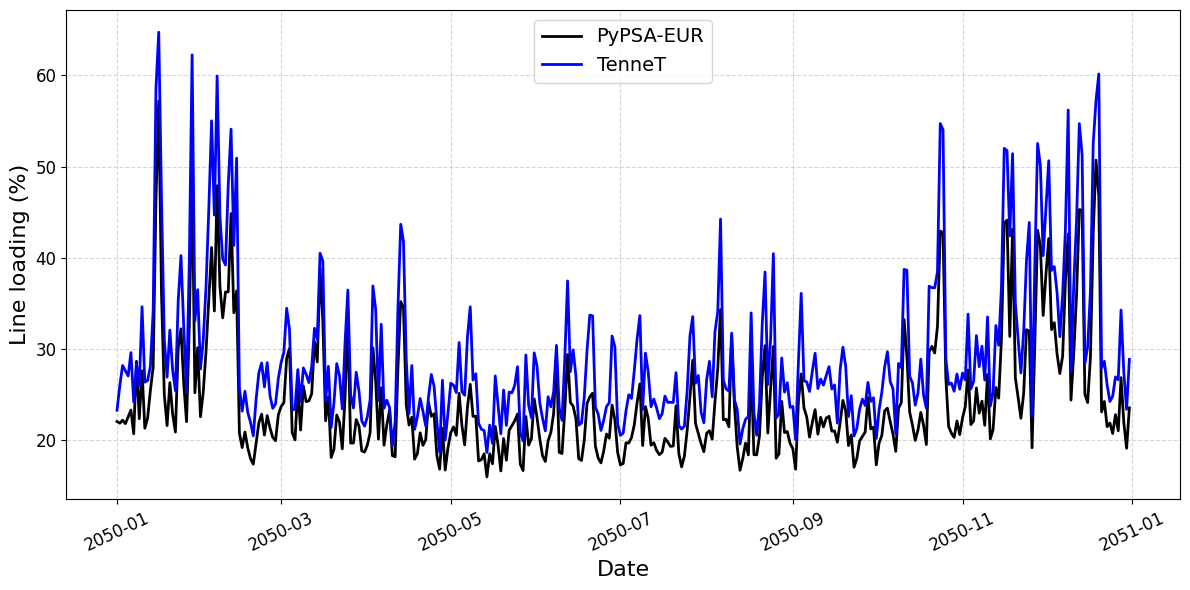

In [7]:
# Load the two CSV files
file1 = "daily_average_pypsa.csv"  # Update with actual filename
file2 = "daily_average_tennet.csv"  # Update with actual filename

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# Ensure the date column is in datetime format
df1["date"] = pd.to_datetime(df1["date"])
df2["date"] = pd.to_datetime(df2["date"])

# Convert line loading to percentage
df1["line_loading"] *= 100
df2["line_loading"] *= 100

# Create the figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the datasets
ax.plot(df1["date"], df1["line_loading"], label="PyPSA-EUR", color="black", linewidth=2, linestyle="-")
ax.plot(df2["date"], df2["line_loading"], label="TenneT", color="blue", linewidth=2, linestyle="-")

# Formatting
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel("Line loading (%)", fontsize=16)
ax.legend(fontsize=14, loc="upper center", frameon=True)
ax.grid(True, linestyle="--", alpha=0.5)

# Improve x-axis readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(rotation=25)

# Adjust margins and layout
plt.tight_layout()

# Save the plot in high quality
plt.savefig("line_loading_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()